In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import os

sns.set_theme(style="whitegrid")

# 2. Ingestão e Limpeza de Dados
Carregamento do dataset do IMDb e remoção de valores nulos, mantendo os registros com zero votos para análise da Cauda Longa profunda.

In [83]:
arquivos = [f for f in os.listdir('/content') if f.endswith('.csv')]
caminho = '/content/' + arquivos[0]
df = pd.read_csv(caminho, engine='python', on_bad_lines='warn')

df.columns = [c.strip().lower() for c in df.columns]
col_votos = 'vote_count' if 'vote_count' in df.columns else [c for c in df.columns if 'vote' in c][0]

df = df.dropna(subset=[col_votos])
df_sorted = df.sort_values(by=col_votos, ascending=False).reset_index(drop=True)
df_sorted['Ranking'] = range(1, len(df_sorted) + 1)

# 3. Análise Estatística: Head/Tail Breaks
Cálculo da Média Aritmética Global para isolar a assimetria da distribuição e identificar o ponto de ruptura do mercado.

## Cálculo da Quantidade Total de Filmes e Média Global de Votos de Filme

Esta seção calcula a média global de votos (`media_global`) e o ponto de corte para segmentar os filmes em Mainstream e Cauda Longa, conforme detalhado na próxima célula.

In [85]:
media_global = df_sorted[col_votos].mean()
corte_index = len(df_sorted[df_sorted[col_votos] >= media_global])

print(f"Total de filmes: {len(df_sorted):,}")
print(f"Média Global: {media_global:.2f} votos")
print(f"Ponto de Corte (Ranking): {corte_index:,}")

Total de filmes: 951,555
Média Global: 22.51 votos
Ponto de Corte (Ranking): 46,038


## Limpeza do dataset antes da geração dos gráficos

O dataset já foi carregado e pré-processado na célula etapa 2, onde nulos foram removidos e a coluna de votos foi convertida para tipo numérico para garantir a consistência dos dados.

## 4. Análise de Viés Geográfico: Mainstream vs. Cauda Longa

Vamos investigar a origem geográfica dos filmes para entender se há um viés regional entre os filmes do Mainstream e da Cauda Longa.

## Gera os Gráficos de comparação entre Filmes Mainstream e Filmes Alternativos

A seguir, apresentamos o gráfico de viés geográfico, que compara a origem dos filmes entre os segmentos Mainstream e Cauda Longa, utilizando as definições de filmes Mainstream e Alternativos baseadas na média global de votos.

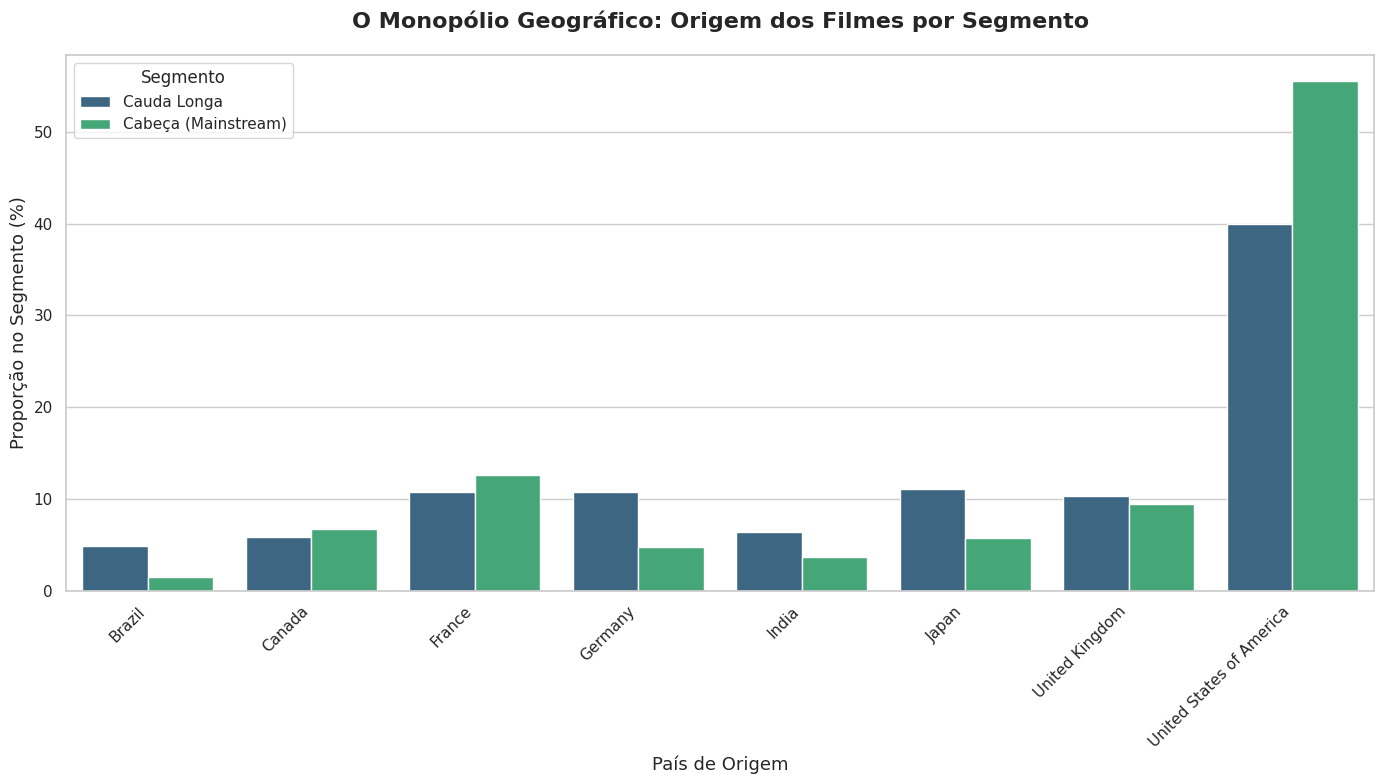

In [90]:
df_geo = df.copy()
df_geo[col_votos] = df_geo[col_votos].fillna(0)

df_geo['Segmento'] = df_geo[col_votos].apply(lambda x: 'Cabeça (Mainstream)' if x >= media_global else 'Cauda Longa')

def get_first_country(countries_str):
    if pd.isna(countries_str) or countries_str.strip() == '[]' or countries_str.strip() == '':
        return None
    try:
        countries_list = eval(countries_str)
        if isinstance(countries_list, list) and len(countries_list) > 0:
            if isinstance(countries_list[0], dict):
                return countries_list[0].get('iso_3166_1') or countries_list[0].get('name')
            else:
                return countries_list[0]
    except:
        if ',' in countries_str:
            return countries_str.split(',')[0].strip()
        return countries_str.strip()
    return None

df_geo['first_country'] = df_geo['production_countries'].apply(get_first_country)

df_geo = df_geo.dropna(subset=['first_country'])

top_8_countries = df_geo['first_country'].value_counts().head(8).index.tolist()

df_geo_filtered = df_geo[df_geo['first_country'].isin(top_8_countries)].copy()

segment_counts = df_geo_filtered['Segmento'].value_counts()

country_segment_counts = df_geo_filtered.groupby(['Segmento', 'first_country']).size().reset_index(name='count')

data_for_plot = []
for segment in segment_counts.index:
    total_in_segment = segment_counts[segment]
    segment_data = country_segment_counts[country_segment_counts['Segmento'] == segment].copy()
    segment_data['percentage'] = (segment_data['count'] / total_in_segment) * 100
    data_for_plot.append(segment_data)

df_plot = pd.concat(data_for_plot)

sns.set_theme(style='whitegrid')

plt.figure(figsize=(14, 8))
sns.barplot(data=df_plot, x='first_country', y='percentage', hue='Segmento', palette='viridis')

plt.title('O Monopólio Geográfico: Origem dos Filmes por Segmento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('País de Origem', fontsize=13)
plt.ylabel('Proporção no Segmento (%)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Segmento', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()